Tranfer learning (TL): focuses on storing knowledged gained while solving one problem and applying it to a diff but related problem 

Ex: Mobilenet V2 Model - trained at google, 1.4 mil images, 1000 classes 

In [7]:
import numpy as np 
import cv2 

import PIL.Image as Image 
import os 
import matplotlib.pyplot as plt 

import tensorflow as tf 
import tensorflow_hub as hub # pip install tensorflow_hub

from tensorflow import keras 
from tensorflow.keras import layers, models 

import tf_keras


### 1. Get the pre-trained model

In [ ]:
IMAGE_SHAPE = (224, 224) # IMAGE_SHAPE+(3,): add the third dimension to the channel 

classifier = tf_keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])


In [28]:
labels_path = tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
imagenet_labels = np.array(open(labels_path).read().splitlines())

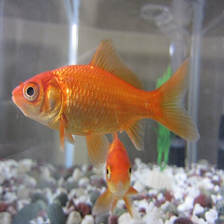

In [ ]:
gold_fish = Image.open("images/goldfish2.jpg").resize(IMAGE_SHAPE)
gold_fish

In [25]:
gold_fish = np.array(gold_fish)/255 
gold_fish

array([[[0.45490196, 0.45490196, 0.50196078],
        [0.45490196, 0.4627451 , 0.50980392],
        [0.47058824, 0.47843137, 0.5254902 ],
        ...,
        [0.31372549, 0.29411765, 0.30980392],
        [0.32156863, 0.30196078, 0.31764706],
        [0.31372549, 0.29411765, 0.30980392]],

       [[0.4627451 , 0.4627451 , 0.50980392],
        [0.47058824, 0.47843137, 0.5254902 ],
        [0.46666667, 0.47843137, 0.52941176],
        ...,
        [0.32156863, 0.30196078, 0.31764706],
        [0.33333333, 0.31372549, 0.3254902 ],
        [0.33333333, 0.31764706, 0.3254902 ]],

       [[0.4745098 , 0.4745098 , 0.52156863],
        [0.47843137, 0.48627451, 0.53333333],
        [0.48235294, 0.49411765, 0.54509804],
        ...,
        [0.32156863, 0.30196078, 0.32156863],
        [0.32156863, 0.30588235, 0.31372549],
        [0.31764706, 0.30196078, 0.30588235]],

       ...,

       [[0.56078431, 0.55294118, 0.55686275],
        [0.57647059, 0.56862745, 0.58039216],
        [0.58431373, 0

In [ ]:
gold_fish[np.newaxis, ...].shape # add 1 more dimension, cause now using only one img

In [26]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result

1/1 [==============================] - 0s 57ms/step


array([[ 0.23433873,  3.4786627 , 11.053975  , ..., -1.9922198 ,
         0.8765894 ,  0.51041114]], shape=(1, 1001), dtype=float32)

In [27]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(2)

In [30]:
imagenet_labels[predicted_label_index]

np.str_('goldfish')

### 2. Flowers Classification

2.1. Get data

In [31]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.', untar=True)

In [33]:
import pathlib

data_dir = pathlib.Path(data_dir) / "flower_photos"

In [37]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [39]:
roses = list(data_dir.glob('roses/*.jpg'))[:5]
roses

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

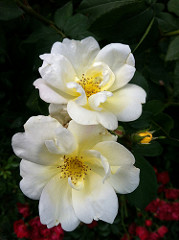

In [57]:
roses_img = Image.open(roses[0])
roses_img

In [42]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4
}

In [43]:
img = cv2.imread(flowers_images_dict['roses'][0]) # read img to cv2 obj (numpy array)
img.shape # img size 

(240, 179, 3)

In [44]:
cv2.resize(img, IMAGE_SHAPE).shape

(224, 224, 3)

In [46]:
X, y = [], [] 

for flower_name, images in flowers_images_dict.items(): 
    for image in images: 
        img = cv2.imread(image)
        resized_img = cv2.resize(img, IMAGE_SHAPE)
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [47]:
X = np.array(X) # convert from python list to np array
y = np.array(y)

In [50]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state =0)

In [51]:
X_train_scaled = X_train/255 
X_test_scaled = X_test/255 

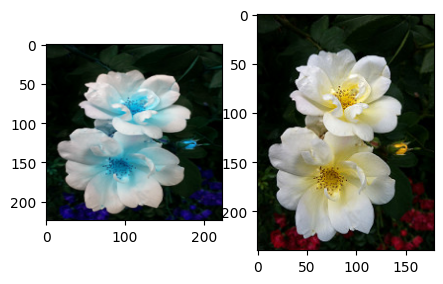

In [76]:
fg, axis = plt.subplots(1, 2, figsize=(5,5))
axis[0].imshow(X[0]) # parameter: np.array 
axis[1].imshow(roses_img) # or PIL img 
plt.show()


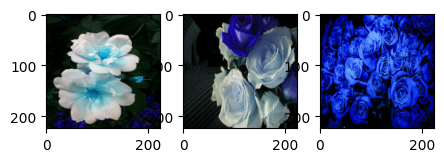

In [ ]:
fg, axis = plt.subplots(1, 3, figsize=(5,5))
axis[0].imshow(X[0])
axis[1].imshow(X[1])
axis[2].imshow(X[2])
plt.show()

2.2. Make predictions with the pre-trained model 

In [67]:
#predicted = classifier.predict(X[0][np.newaxis, ...]) # only imge 
predicted = classifier.predict(np.array([X[0], X[1], X[2]])) # only imge 
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 0s 64ms/step


array([795, 880, 795])

In [68]:
imagenet_labels[predicted]

array(['shower curtain', 'umbrella', 'shower curtain'], dtype='<U30')

2.3 Re-train the model

In [88]:
# feature_vector path
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, 
    input_shape=(224, 224,3), 
    trainable=False # freeze weights
)

In [91]:
num_of_flowers = 5 

model = tf_keras.Sequential([
    pretrained_model_without_top_layer, 
    tf_keras.layers.Dense(num_of_flowers) # add the last model 
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_5 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [93]:
model.compile(
    optimizer='adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train, epochs= 5)

Epoch 1/5
86/86 [==============================] - 30s 298ms/step - loss: 0.7381 - accuracy: 0.7326
Epoch 2/5
86/86 [==============================] - 26s 304ms/step - loss: 0.3952 - accuracy: 0.8601
Epoch 3/5
86/86 [==============================] - 22s 257ms/step - loss: 0.3071 - accuracy: 0.8957
Epoch 4/5
86/86 [==============================] - 22s 261ms/step - loss: 0.2636 - accuracy: 0.9110
Epoch 5/5
86/86 [==============================] - 23s 263ms/step - loss: 0.2229 - accuracy: 0.9320
